# **Computer Vision based bikeability Score**

## 1. Setup & Imports

In [1]:
import csv
import datetime as dt
import math
import os
import sys
import time
from pathlib import Path

import cv2
import numpy as np
import torch

# Auf CPU-only alle Kerne für die Modelle nutzen (Torch nutzt sonst evtl. weniger).
_n_cpu = os.cpu_count() or 1
torch.set_num_threads(_n_cpu)
cv2.setNumThreads(_n_cpu)

# Projekt-Root (dieses Notebook liegt im Repo-Root) auf den Importpfad legen,
# damit das detectors-Paket gefunden wird.
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from detectors.ground_detection import GroundDetector
from detectors.object_detection import ObjectDetector
from detectors.environment_detection import EnvironmentDetector


## 2. Konfiguration: Bewertungstabellen & Gewichte

Der Score setzt sich aus **drei Teilkomponenten** zusammen, die jeweils von einem eigenen Modell
kommen:

- **Ground Detection** → Oberflächenklasse (Asphalt, Schotter, Erde, …)
- **Environment Detection** → Umgebungsklasse (Natur, Stadt, Industrie, …)
- **Object Detection** → Objektzählungen (Autos, Fußgänger, Radfahrer, …)

Jede Klasse bekommt eine feste Bewertung in `[0, 1]`. Objekte erhalten einen *Störfaktor*
(negativ = fahrradfreundlich, z. B. andere Radfahrer). Die drei Subscores werden über die
Gewichte `W_GROUND + W_ENV + W_OBJECT = 1` zum Gesamtscore kombiniert – dadurch bleibt der Score
**garantiert** in `[0, 100]`.

> Die Werte sind heuristisch


In [2]:
# --- Gewichte der drei Teilkomponenten (Summe = 1.0) ---
W_GROUND = 0.2
W_ENV = 0.45
W_OBJECT = 0.35

# Bewertungs-/Straf-Vektoren als Arrays – EXAKT in der Reihenfolge der Detektor-Klassen.
# Ground (One-Hot): GroundDetector.classes = ("Cycleway", "Road", "Gravel", "Unpaved")
GROUND_QUALITY = np.array([1.0, 0.7, 0.3, 0.1], dtype=float)

# Environment (Fractions): EnvironmentDetector.classes = ("vegetation", "water", "city")
ENV_QUALITY = np.array([1.0, 1.0, 0.4], dtype=float)

# Object (Counts): ObjectDetector.classes = ("bicycle", "car", "traffic light")
# negativ = fahrradfreundlich (bicycle); Auto wird am stärksten bestraft.
OBJECT_PENALTY = np.array([-0.2, 1.0, 0.3], dtype=float)

print("Konfiguration geladen.")
print(f"  Gewichte: ground={W_GROUND}, env={W_ENV}, object={W_OBJECT} "
      f"(Summe={W_GROUND + W_ENV + W_OBJECT:.2f})")
print(f"  Ground : {GroundDetector.classes} -> {GROUND_QUALITY.tolist()}")
print(f"  Env    : {EnvironmentDetector.classes} -> {ENV_QUALITY.tolist()}")
print(f"  Object : {ObjectDetector.classes} -> {OBJECT_PENALTY.tolist()}")


Konfiguration geladen.
  Gewichte: ground=0.2, env=0.45, object=0.35 (Summe=1.00)
  Ground : ('Cycleway', 'Road', 'Gravel', 'Unpaved') -> [1.0, 0.7, 0.3, 0.1]
  Env    : ('vegetation', 'water', 'city') -> [1.0, 1.0, 0.4]
  Object : ('bicycle', 'car', 'traffic light') -> [-0.2, 1.0, 0.3]


## 3. Bikeability-Score-Funktion

Aus den drei Modell-Ausgaben (jeweils **NumPy-Arrays**) wird pro Frame ein Score in `[0, 100]` berechnet:

$$
A = 100 \cdot \Big( w_g \cdot S_{\text{ground}} + w_e \cdot S_{\text{env}} + w_o \cdot S_{\text{object}} \Big)
$$

- **Ground-Subscore:** Skalarprodukt des **One-Hot-Arrays** (`[Cycleway, Road, Gravel, Unpaved]`) mit dem
  Qualitätsvektor `GROUND_QUALITY` – wählt effektiv die Qualität der erkannten Klasse.
- **Env-Subscore:** gewichtetes Mittel über die **Fractions** (`[vegetation, water, city]`), also
  `⟨frac, ENV_QUALITY⟩ / Σ frac` (neutral `0.5`, falls keine Umgebungsklasse erkannt wird).
- **Object-Subscore:** Sättigungsfunktion $e^{-\max(0,\ \langle counts, \lambda\rangle / N)}$ über die
  **Counts** (`[bicycle, car, traffic light]`) – robust gegen Ausreißer.


In [3]:
def ground_subscore(ground_onehot) -> float:
    """Oberflächen-Subscore in [0, 1] aus dem One-Hot-Array der Ground-Detection."""
    return float(np.dot(np.asarray(ground_onehot, dtype=float), GROUND_QUALITY))


def env_subscore(env_fractions) -> float:
    """Umgebungs-Subscore in [0, 1] aus den Environment-Fractions (Flächenanteile).

    Gewichtetes Mittel der Klassenqualität über die erkannten Umgebungsanteile.
    Wird gar keine Umgebungsklasse erkannt (Summe 0), gilt ein neutraler Wert 0.5.
    """
    frac = np.asarray(env_fractions, dtype=float)
    total = frac.sum()
    if total <= 0.0:
        return 0.5
    return float(np.dot(frac, ENV_QUALITY) / total)


def object_subscore(object_counts, n_frames: int = 1) -> float:
    """Objekt-Subscore in (0, 1] aus den Objektzählungen (Sättigungsfunktion)."""
    counts = np.asarray(object_counts, dtype=float)
    density = float(np.dot(counts, OBJECT_PENALTY)) / max(n_frames, 1)
    return float(math.exp(-max(density, 0.0)))


def bikeability_score(
    ground_onehot,
    env_fractions,
    object_counts,
    n_frames: int = 1,
) -> float:
    s_g = ground_subscore(ground_onehot)
    s_e = env_subscore(env_fractions)
    s_o = object_subscore(object_counts, n_frames)
    score = 100.0 * (W_GROUND * s_g + W_ENV * s_e + W_OBJECT * s_o)
    return round(score, 2)


# --- Kurzer Funktionstest mit Beispiel-Arrays ---
_demo = bikeability_score(
    ground_onehot=[0, 1, 0, 0],       # Road
    env_fractions=[0.6, 0.0, 0.1],    # viel Vegetation, etwas Stadt
    object_counts=[2, 1, 0],          # 2 Räder, 1 Auto, 0 Ampeln
)
print(f"Demo-Score (Road, Vegetation, 2 Räder/1 Auto): {_demo}/100")


Demo-Score (Road, Vegetation, 2 Räder/1 Auto): 74.35/100


## 4. Video-Verarbeitung: Ganzer Ordner, Score alle 5 Sekunden

Die DJI-Kamera teilt eine durchgehende Aufnahme in **mehrere Videodateien** auf
(`DJI_0408` → `DJI_0409` → …). Man legt daher einfach **alle Teile** in den Ordner
`dataset/input_videos` und lässt sie in einem Rutsch verarbeiten.

`find_videos` sammelt alle Videodateien und sortiert sie **chronologisch** anhand der
Zahl im Dateinamen. `process_video_folder` verarbeitet sie dann **nacheinander wie ein
einziges Video**:

1. öffnet jeden Videoteil und ermittelt dessen **FPS**,
2. extrahiert **alle 5 Sekunden** genau ein Frame (gezieltes Seeken statt alle Frames zu
   dekodieren),
3. ruft für jedes Frame die **drei Detektoren** auf (`GroundDetector`,
   `EnvironmentDetector`, `ObjectDetector`) – die Modelle werden **einmal** vor der
   Schleife geladen,
4. berechnet den **Bikeability-Score** und schreibt jede Zeile in **eine gemeinsame CSV**.

**Lückenlose Zeitachse:** Über einen kumulativen `time_offset_seconds` (Summe der Dauern
der bereits verarbeiteten Teile) laufen `time_seconds`, `timestamp` (und ggf. der absolute
`abs_timestamp`) über alle Teile hinweg **durchgehend** weiter – der erste Frame von
`DJI_0409` schließt also nahtlos an das Ende von `DJI_0408` an.

Der `frame_name` (`<video>_frame_<index>`) enthält den Namen des jeweiligen Videoteils und
bleibt damit über alle Dateien hinweg eindeutig. Die Arrays der drei Modelle werden als
`;`-getrennte Strings serialisiert (`ground`, `environment`, `objects`).


In [4]:
import re

CSV_FIELDS = [
    "frame_index",
    "frame_name",
    "time_seconds",
    "timestamp",
    "abs_timestamp",
    "ground",
    "environment",
    "objects",
    "score",
]

# Unterstützte Videoformate im input_videos-Ordner (DJI liefert .MP4).
VIDEO_EXTENSIONS = (".mp4", ".mov", ".avi", ".mkv", ".m4v")


def _video_sort_key(path: Path):
    """Sortier-Key für chronologische Reihenfolge der Videoteile.

    Nutzt die letzte Zahlengruppe im Dateinamen (z. B. DJI_0408 -> 408), damit
    DJI_0408 < DJI_0409 < ... korrekt geordnet wird. Fallback: alphabetisch.
    """
    numbers = re.findall(r"\d+", path.stem)
    return (int(numbers[-1]) if numbers else -1, path.stem.lower())


def find_videos(folder: str | Path) -> list[Path]:
    """Alle Videodateien eines Ordners chronologisch sortiert zurückgeben."""
    folder = Path(folder)
    if not folder.is_dir():
        raise NotADirectoryError(f"Video-Ordner nicht gefunden: {folder}")
    videos = [p for p in folder.iterdir()
              if p.is_file() and p.suffix.lower() in VIDEO_EXTENSIONS]
    return sorted(videos, key=_video_sort_key)


def process_video(
    video_path: str | Path,
    writer: csv.DictWriter,
    ground_detector: GroundDetector,
    env_detector: EnvironmentDetector,
    object_detector: ObjectDetector,
    interval_seconds: float = 5.0,
    video_start_time: dt.datetime | None = None,
    time_offset_seconds: float = 0.0,
    batch_size: int = 8,
    timings: dict | None = None,
) -> tuple[list[dict], float]:
    """Verarbeitet EIN Video und schreibt die Ergebniszeilen in den offenen CSV-Writer.

    `time_offset_seconds` verschiebt alle Zeitangaben, sodass mehrere Videoteile
    lückenlos aneinander anschließen (Timestamp des ersten Frames = Offset).
    Rückgabe: (results, video_duration_seconds).
    """
    video_path = Path(video_path)

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Video konnte nicht geöffnet werden: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    if not fps or fps <= 0:
        fps = 30.0
        print("⚠ FPS konnten nicht gelesen werden - Fallback auf 30 fps.")

    frame_interval = max(1, round(fps * interval_seconds))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration_seconds = total_frames / fps if fps > 0 else 0.0
    # Nur die tatsächlich benötigten Frame-Indizes – wir SEEKEN gezielt dorthin,
    # statt jedes Frame zu dekodieren (spart ~99 % der Decode-Arbeit).
    target_indices = list(range(0, max(total_frames, 1), frame_interval))

    print(f"Video      : {video_path.name}")
    print(f"FPS        : {fps:.2f}")
    print(f"Frames ges.: {total_frames}")
    print(f"Startoffset: {str(dt.timedelta(seconds=int(time_offset_seconds)))}")
    print(f"Auswertung : alle {interval_seconds:.0f}s  ->  {len(target_indices)} Frames "
          f"(jedes {frame_interval}.), Batch={batch_size}")

    if timings is None:
        timings = {"decode": 0.0, "ground": 0.0, "env": 0.0, "object": 0.0}
    results: list[dict] = []

    for chunk_start in range(0, len(target_indices), batch_size):
        chunk = target_indices[chunk_start:chunk_start + batch_size]

        # --- Frames dieses Batches gezielt einlesen (Seek statt Read-all) ---
        t0 = time.perf_counter()
        frames: list[np.ndarray] = []
        frame_idxs: list[int] = []
        for idx in chunk:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ok, frame = cap.read()
            if ok:
                frames.append(frame)
                frame_idxs.append(idx)
        timings["decode"] += time.perf_counter() - t0
        if not frames:
            continue

        # --- Modelle gebündelt (Batch) aufrufen ---
        t0 = time.perf_counter()
        ground_batch = ground_detector.detect_batch(frames)     # [B, 4]
        timings["ground"] += time.perf_counter() - t0

        t0 = time.perf_counter()
        env_batch = env_detector.detect_batch(frames)           # [B, 3]
        timings["env"] += time.perf_counter() - t0

        t0 = time.perf_counter()
        object_batch = object_detector.detect_batch(frames)     # [B, 3]
        timings["object"] += time.perf_counter() - t0

        for frame_index, ground_onehot, env_fractions, object_counts in zip(
                frame_idxs, ground_batch, env_batch, object_batch):
            # Lokale Videozeit + kumulativer Offset => durchgehende Zeitachse.
            time_seconds = time_offset_seconds + frame_index / fps
            score = bikeability_score(ground_onehot, env_fractions, object_counts)

            abs_timestamp = ""
            if video_start_time is not None:
                abs_timestamp = (
                    video_start_time + dt.timedelta(seconds=time_seconds)
                ).isoformat()

            row = {
                "frame_index": frame_index,
                "frame_name": f"{video_path.stem}_frame_{frame_index:06d}",
                "time_seconds": round(time_seconds, 3),
                "timestamp": str(dt.timedelta(seconds=int(time_seconds))),
                "abs_timestamp": abs_timestamp,
                "ground": ";".join(map(str, ground_onehot.tolist())),
                "environment": ";".join(f"{v:.4f}" for v in env_fractions.tolist()),
                "objects": ";".join(map(str, object_counts.tolist())),
                "score": score,
            }
            writer.writerow(row)
            results.append(row)

    cap.release()
    return results, duration_seconds


def process_video_folder(
    video_dir: str | Path,
    output_csv: str | Path,
    ground_detector: GroundDetector,
    env_detector: EnvironmentDetector,
    object_detector: ObjectDetector,
    interval_seconds: float = 5.0,
    video_start_time: dt.datetime | None = None,
    batch_size: int = 8,
) -> list[dict]:
    """Verarbeitet ALLE Videoteile eines Ordners als EIN durchgehendes Video.

    Die Videos werden chronologisch sortiert (DJI_0408 -> DJI_0409 -> ...) und
    nacheinander verarbeitet. Über einen kumulativen Zeit-Offset (Summe der
    bisherigen Video-Dauern) bleiben die Timestamps lückenlos fortlaufend – so,
    als wäre die von der DJI-Kamera geteilte Aufnahme ein einziges Video.
    Alle Ergebnisse landen in EINER gemeinsamen CSV.
    """
    video_dir = Path(video_dir)
    output_csv = Path(output_csv)

    videos = find_videos(video_dir)
    if not videos:
        raise FileNotFoundError(
            f"Keine Videos in {video_dir} gefunden (Endungen: {VIDEO_EXTENSIONS})."
        )

    print(f"Gefundene Videoteile ({len(videos)}) – chronologische Reihenfolge:")
    for i, v in enumerate(videos, 1):
        print(f"  {i:>2}. {v.name}")
    print("=" * 50)

    timings = {"decode": 0.0, "ground": 0.0, "env": 0.0, "object": 0.0}
    all_results: list[dict] = []
    time_offset = 0.0
    t_start = time.perf_counter()

    with output_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=CSV_FIELDS)
        writer.writeheader()

        for video_path in videos:
            results, duration = process_video(
                video_path=video_path,
                writer=writer,
                ground_detector=ground_detector,
                env_detector=env_detector,
                object_detector=object_detector,
                interval_seconds=interval_seconds,
                video_start_time=video_start_time,
                time_offset_seconds=time_offset,
                batch_size=batch_size,
                timings=timings,
            )
            all_results.extend(results)
            time_offset += duration
            print(f"  -> {len(results)} Frames, kumulierte Gesamtzeit: "
                  f"{str(dt.timedelta(seconds=int(time_offset)))}")
            print("-" * 50)

    total = time.perf_counter() - t_start
    print(f"Fertig: {len(all_results)} Frames über {len(videos)} Videoteile "
          f"-> {output_csv.resolve()}")
    print(f"Gesamte Videodauer : {str(dt.timedelta(seconds=int(time_offset)))}")
    print("-" * 50)
    print(f"Verarbeitungszeit  : {total:6.1f}s")
    for name, sec in timings.items():
        share = 100.0 * sec / total if total > 0 else 0.0
        print(f"  {name:<8}: {sec:6.1f}s  ({share:4.1f} %)")
    return all_results


## 5. Ausführung & Durchschnitts-Score

Alle Videoteile im Ordner `dataset/input_videos` chronologisch als **ein durchgehendes
Video** verarbeiten, die Ergebnisse als Array + gemeinsame CSV erhalten und den
**durchschnittlichen Bikeability-Score** über alle ausgewerteten Frames berechnen.


In [12]:
# Ordner mit ALLEN Videoteilen (DJI teilt eine Aufnahme in mehrere Dateien auf).
VIDEO_DIR = Path("dataset/input_videos")

# Alle Ergebnisse landen im output-Ordner (wird bei Bedarf angelegt).
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_CSV = OUTPUT_DIR / "bikeability_scores.csv"

VIDEO_START_TIME = None

ground_detector = GroundDetector()
env_detector = EnvironmentDetector()
object_detector = ObjectDetector()

# --- Alle Videoteile im Ordner als ein durchgehendes Video verarbeiten ----------
scores = process_video_folder(
    video_dir=VIDEO_DIR,
    output_csv=OUTPUT_CSV,
    ground_detector=ground_detector,
    env_detector=env_detector,
    object_detector=object_detector,
    interval_seconds=5.0,
    video_start_time=VIDEO_START_TIME,
)

# --- Durchschnitts-Score berechnen ----------------------------------------------
if scores:
    values = [row["score"] for row in scores]
    average_score = round(sum(values) / len(values), 2)
    print("-" * 50)
    print(f"Ausgewertete Frames : {len(values)}")
    print(f"Min / Max Score     : {min(values):.2f} / {max(values):.2f}")
    print(f"⌀ Durchschnitt      : {average_score}/100")
else:
    average_score = None
    print("Keine Frames ausgewertet - Durchschnitt nicht berechenbar.")


Gefundene Videoteile (5) – chronologische Reihenfolge:
   1. DJI_0408.MP4
   2. DJI_0409.MP4
   3. DJI_0410.MP4
   4. DJI_0411.MP4
   5. DJI_0412.MP4
Video      : DJI_0408.MP4
FPS        : 25.00
Frames ges.: 23277
Startoffset: 0:00:00
Auswertung : alle 5s  ->  187 Frames (jedes 125.), Batch=8
  -> 187 Frames, kumulierte Gesamtzeit: 0:15:31
--------------------------------------------------
Video      : DJI_0409.MP4
FPS        : 25.00
Frames ges.: 23327
Startoffset: 0:15:31
Auswertung : alle 5s  ->  187 Frames (jedes 125.), Batch=8
  -> 187 Frames, kumulierte Gesamtzeit: 0:31:04
--------------------------------------------------
Video      : DJI_0410.MP4
FPS        : 25.00
Frames ges.: 23436
Startoffset: 0:31:04
Auswertung : alle 5s  ->  188 Frames (jedes 125.), Batch=8
  -> 188 Frames, kumulierte Gesamtzeit: 0:46:41
--------------------------------------------------
Video      : DJI_0411.MP4
FPS        : 25.00
Frames ges.: 23484
Startoffset: 0:46:41
Auswertung : alle 5s  ->  188 Frames

## 6. (Optional) Scores auf den GPS-Track mappen

Die pro Frame berechneten Bikeability-Scores werden mit dem GPS-Track aus
`dataset/input_gpx/` verknüpft und als Karte dargestellt: **0 = tiefrot**,
**100 = grün**, dazwischen orange/gelb/hellgrün (`RdYlGn`).

**Zeitstempel-Problem:** Die Kamera-Uhr der DJI ist unbrauchbar (analog zu
`research/other/merge_mp4_gpx.ipynb`). Deshalb wird die Startzeit über einen
**manuellen Sync-Punkt** bestimmt – standardmäßig die Annahme *Aufnahme-Start
(`time_seconds = 0`) = GPX-Track-Start*. Über `SYNC_GPX_TIME` /
`SYNC_TIME_SECONDS` lässt sich das bei Bedarf korrigieren.

Ergebnisse: `output/score_with_gpx.csv` (gemergte Tabelle) und
`output/bikeability_map.png` (Karte).


In [13]:
import xml.etree.ElementTree as ET

import pandas as pd
import matplotlib.pyplot as plt

# --- Pfade -----------------------------------------------------------------------
GPX_DIR = Path("dataset/input_gpx")
MERGED_CSV = OUTPUT_DIR / "score_with_gpx.csv"
PLOT_PATH = OUTPUT_DIR / "bikeability_map.png"

MATCH_TOLERANCE_S = 3.0   # max. Zeitabstand Score-Frame <-> GPS-Punkt (Sekunden)

# --- Sync-Konfiguration (Kamera-Zeitstempel ist unbrauchbar!) --------------------
# time_seconds == SYNC_TIME_SECONDS entspricht der echten UTC-Zeit SYNC_GPX_TIME.
# SYNC_GPX_TIME = None  =>  Annahme: Aufnahme-Start (time_seconds=0) = GPX-Start.
SYNC_TIME_SECONDS = 0.0
SYNC_GPX_TIME = None      # z. B. "2026-07-12T17:36:12Z"

GPX_NS = {"gpx": "http://www.topografix.com/GPX/1/1"}


def load_gpx(path: Path) -> pd.DataFrame:
    """GPX-Track als DataFrame (time, lat, lon, ele)."""
    tree = ET.parse(path)
    rows = []
    for trkpt in tree.findall(".//gpx:trkpt", GPX_NS):
        t = trkpt.find("gpx:time", GPX_NS)
        ele = trkpt.find("gpx:ele", GPX_NS)
        rows.append({
            "time": dt.datetime.fromisoformat(t.text.replace("Z", "+00:00")),
            "lat": float(trkpt.get("lat")),
            "lon": float(trkpt.get("lon")),
            "ele": float(ele.text) if ele is not None else np.nan,
        })
    return pd.DataFrame(rows).sort_values("time").reset_index(drop=True)


# --- GPX automatisch finden ------------------------------------------------------
gpx_files = sorted(GPX_DIR.glob("*.gpx"))
if not gpx_files:
    raise FileNotFoundError(f"Keine GPX-Datei in {GPX_DIR} gefunden.")
if len(gpx_files) > 1:
    print(f"⚠ Mehrere GPX-Dateien gefunden – nutze die erste: {gpx_files[0].name}")
gpx_path = gpx_files[0]

gpx = load_gpx(gpx_path)
gpx_start = gpx["time"].iloc[0]
print(f"GPX-Datei   : {gpx_path.name}")
print(f"GPX-Punkte  : {len(gpx)}")
print(f"Zeitraum    : {gpx_start}  →  {gpx['time'].iloc[-1]}")

# --- Score-CSV laden -------------------------------------------------------------
score_df = pd.read_csv(OUTPUT_CSV)
print(f"Score-Frames: {len(score_df)}")

# --- Startzeit (time_seconds = 0) bestimmen --------------------------------------
if SYNC_GPX_TIME is not None:
    sync_time = dt.datetime.fromisoformat(SYNC_GPX_TIME.replace("Z", "+00:00"))
else:
    sync_time = gpx_start
    print("ℹ Kein Sync gesetzt → Annahme: Aufnahme-Start = GPX-Start.")

video_start_utc = sync_time - pd.Timedelta(seconds=SYNC_TIME_SECONDS)
print(f"Aufnahme-Start (t=0, UTC): {video_start_utc}")

# Echte UTC-Zeit je Score-Frame aus der fortlaufenden time_seconds-Achse
score_df["time"] = video_start_utc + pd.to_timedelta(score_df["time_seconds"], unit="s")

# --- Nearest-Match Score-Frame <-> GPX-Punkt -------------------------------------
# Beide time-Spalten auf dieselbe Auflösung (ns) bringen – merge_asof verlangt
# identische dtypes (GPX kommt als us, Score als ns).
score_df["time"] = score_df["time"].astype("datetime64[ns, UTC]")
gpx_match = gpx.copy()
gpx_match["time"] = gpx_match["time"].astype("datetime64[ns, UTC]")
gpx_match["gpx_time"] = gpx_match["time"]

merged = pd.merge_asof(
    score_df.sort_values("time"),
    gpx_match.sort_values("time"),
    on="time",
    direction="nearest",
    tolerance=pd.Timedelta(seconds=MATCH_TOLERANCE_S),
)
merged["dt_s"] = (merged["gpx_time"] - merged["time"]).dt.total_seconds().abs()
matched = int(merged["lat"].notna().sum())

print(f"Zugeordnet (≤{MATCH_TOLERANCE_S}s): {matched} / {len(merged)}")
if matched:
    print(f"Max. Zeitabstand         : {merged['dt_s'].max():.2f} s")

MERGED_CSV.parent.mkdir(parents=True, exist_ok=True)
merged.to_csv(MERGED_CSV, index=False)
print(f"💾 gespeichert: {MERGED_CSV.resolve()}")
merged[["frame_name", "time_seconds", "time", "lat", "lon", "score"]].head()


GPX-Datei   : Radfahrt_am_Abend.gpx
GPX-Punkte  : 4342
Zeitraum    : 2026-07-12 17:36:12+00:00  →  2026-07-12 18:52:25+00:00
Score-Frames: 917
ℹ Kein Sync gesetzt → Annahme: Aufnahme-Start = GPX-Start.
Aufnahme-Start (t=0, UTC): 2026-07-12 17:36:12+00:00
Zugeordnet (≤3.0s): 874 / 917
Max. Zeitabstand         : 2.84 s
💾 gespeichert: C:\Users\aydem\Documents\DHBW\computer_vision\computer_vision_bikeability_score\final_bikeability_score\output\score_with_gpx.csv


,frame_name,time_seconds,time,lat,lon,score
0,DJI_0408_frame_000000,0.0,2026-07-12 17:36:12+00:00,48.950586,9.119179,100.00
1,DJI_0408_frame_000125,5.0,2026-07-12 17:36:17+00:00,48.950444,9.118954,100.00
2,DJI_0408_frame_000250,10.0,2026-07-12 17:36:22+00:00,48.950267,9.118694,77.88
3,DJI_0408_frame_000375,15.0,2026-07-12 17:36:27+00:00,48.950047,9.118360,100.00
4,DJI_0408_frame_000500,20.0,2026-07-12 17:36:32+00:00,48.949844,9.118056,63.74


💾 Map saved: C:\Users\aydem\Documents\DHBW\computer_vision\computer_vision_bikeability_score\final_bikeability_score\output\bikeability_map.png


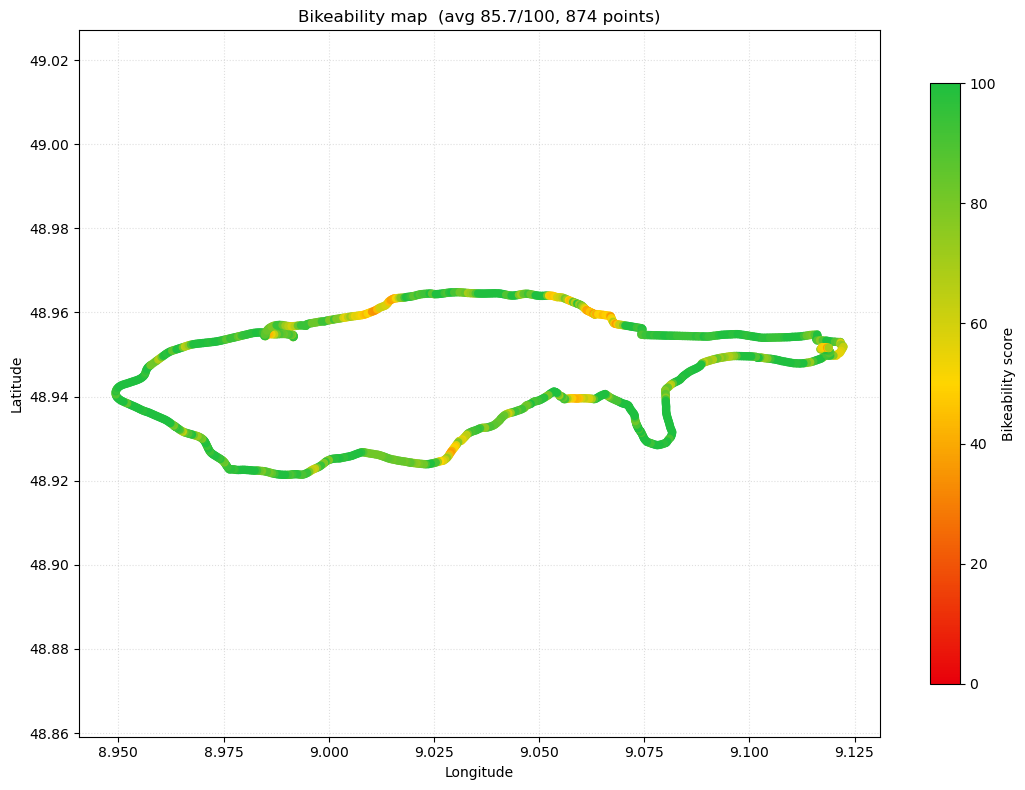

In [15]:
# --- Draw the bikeability map ----------------------------------------------------
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, Normalize

# Only plot points that were matched to a valid GPS position.
plot_df = merged.dropna(subset=["lat", "lon"]).sort_values("time").copy()
if plot_df.empty:
    raise ValueError("No score points with a GPS position - cannot build the map.")

# Custom colormap: bright red -> yellow -> bright green (0 = bad, 100 = good).
bikeability_cmap = LinearSegmentedColormap.from_list(
    "bikeability", ["#e8000b", "#ffd500", "#1fbf3f"]
)
norm = Normalize(vmin=0, vmax=100)

lons = plot_df["lon"].to_numpy()
lats = plot_df["lat"].to_numpy()
scores = plot_df["score"].to_numpy()

fig, ax = plt.subplots(figsize=(11, 8))

# Full GPX track as a thin grey line in the background.
ax.plot(gpx["lon"], gpx["lat"], color="lightgray", linewidth=1.2, zorder=1)

# Smooth colored ribbon: one continuous line colored by score, no markers.
points = np.array([lons, lats]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
seg_scores = (scores[:-1] + scores[1:]) / 2.0  # color each segment by mean score
lc = LineCollection(
    segments,
    cmap=bikeability_cmap,
    norm=norm,
    linewidths=6,
    capstyle="round",
    joinstyle="round",
    zorder=2,
)
lc.set_array(seg_scores)
ax.add_collection(lc)

cbar = fig.colorbar(lc, ax=ax, shrink=0.85)
cbar.set_label("Bikeability score")

ax.set_title(f"Bikeability map  (avg {scores.mean():.1f}/100, {len(plot_df)} points)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="datalim")
ax.margins(0.05)
ax.grid(True, linestyle=":", alpha=0.4)

fig.tight_layout()
fig.savefig(PLOT_PATH, dpi=150, bbox_inches="tight")
print(f"💾 Map saved: {PLOT_PATH.resolve()}")
plt.show()
